# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**ResNet-18 Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a ResNet-18 model on the Pneumonia dataset without data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [8]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.resnet_utils import build_resnet18, DropoutRateScheduler
from utils.train_utils import get_callbacks, train_model
from utils.eval_utils import evaluate_model, compare_models
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix

# Core Variables

In [9]:
# Global variables
DATA_PATH = '../data/'
MODEL_PATH = '../models/'
MODEL_NAME = 'resnet_18' # Name of the model to be saved

# Training parameters
BATCH_SIZE = 32 # + 64 and 128
EPOCHS = 100
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.5 # + 0.3 and costum sheduler
DROPOUT_RATE_START = 0.5
DROPOUT_RATE_END = 0.3
MODE = 'max'
CHOSEN_METRIC = 'val_AUC' # Metric to be used for model selection, e.g. 'val_loss', 'val_AUC', 'val_accuracy'

FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_b{BATCH_SIZE}_lr{LEARNING_RATE}_pneumonia_model.keras'

# Data Loading & Preprocessing

In [10]:
train_images, train_labels, test_images, test_labels, val_images, val_labels = load_and_preprocess_data(DATA_PATH)


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)


# ResNet-18 Model

## Creation & Compilation

In [11]:
# Create and compile model
model = build_resnet18(dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 28, 28,    │        640 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 28, 28,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 28, 28,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 14, 14,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 14, 14,    │     36,928 │ maxpool1[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ maxpool1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 14, 14,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 14, 14,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 14, 14,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 14, 14,    │        256 │ stage1_block2_co

 Total params: 11,183,106 (42.66 MB)

 Trainable params: 11,173,506 (42.62 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [ ]:
# dropout_scheduler = DropoutRateScheduler(dropout_start=DROPOUT_RATE_START, dropout_end=DROPOUT_RATE_END, epochs=EPOCHS)

## Training

Epoch 1/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 36s 140ms/step - AUC: 0.9370 - accuracy: 0.8816 - loss: 0.4157 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 3.3684
Epoch 2/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - AUC: 0.9933 - accuracy: 0.9606 - loss: 0.1028 - val_AUC: 0.7424 - val_accuracy: 0.7424 - val_loss: 4.0259
Epoch 3/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - AUC: 0.9923 - accuracy: 0.9620 - loss: 0.1067 - val_AUC: 0.9122 - val_accuracy: 0.7996 - val_loss: 0.7840
Epoch 4/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - AUC: 0.9954 - accuracy: 0.9720 - loss: 0.0785 - val_AUC: 0.9749 - val_accuracy: 0.9237 - val_loss: 0.2412
Epoch 5/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - AUC: 0.9955 - accuracy: 0.9720 - loss: 0.0759 - val_AUC: 0.9941 - val_accuracy: 0.9599 - val_loss: 0.1029
Epoch 6/100
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - AUC: 0.9969 - accuracy: 0.9760 - loss: 0.0664 - val_AUC: 0.9904 - val_accuracy: 0.9542 - val_loss: 0.1199
Epoch 7/100
148/148 ━

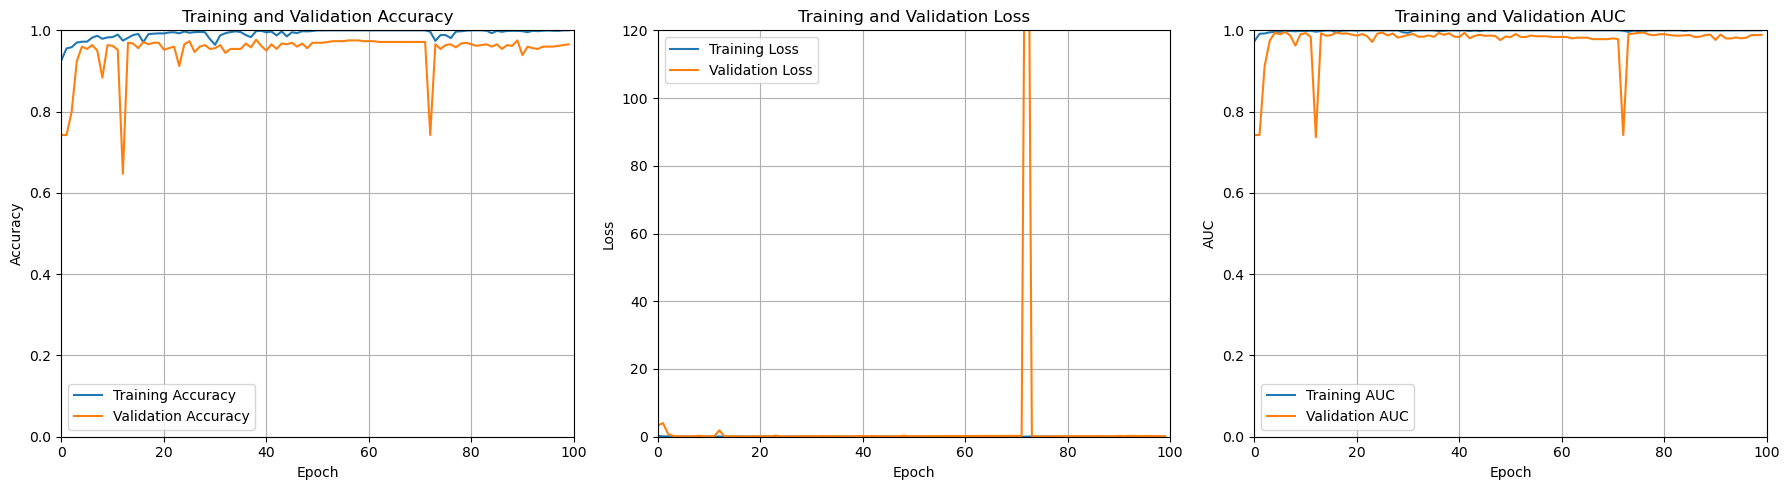

In [12]:
# Train model
history = train_model(
    model, 
    train_images, train_labels,
    val_images, val_labels,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE
)

# Plot training history
plot_training_history(history, epochs=EPOCHS)

# Save final model
model.save(FINAL_MODEL_PATH)

## Evaluation

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - AUC: 0.8625 - accuracy: 0.8452 - loss: 1.6202
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


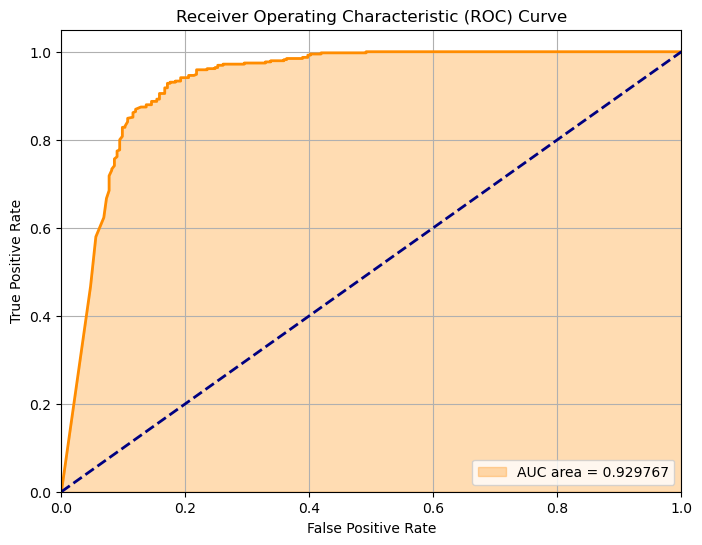

ROC AUC Score: 0.9298


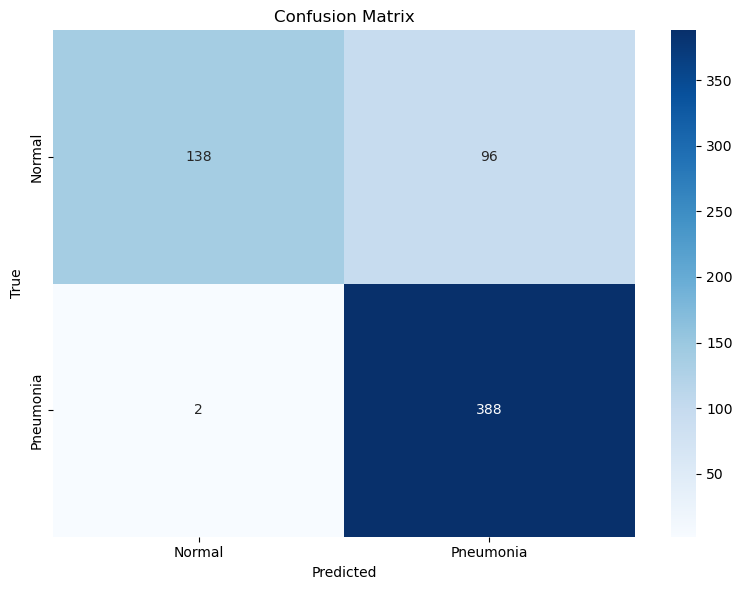

              precision    recall  f1-score   support

      Normal       0.99      0.59      0.74       234
   Pneumonia       0.80      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



In [14]:
# Evaluate model
results = evaluate_model(model, test_images, test_labels)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])